In [2]:
# ===== DATE SELECTION KNOB =====
# Leave empty [] to process all dates, or specify one or more dates as strings in "YYYYMMDD" format
# selected_dates = [] # for all dates
selected_dates = ["20260129"]  # <-- MODIFY THIS to select specific dates

# ===== PLOT SETTINGS ===== CHANGE AS NEEDED =====
plot_all_traces = "Y"  # "Y" to plot all, "N" to skip; high current traces are always plotted

Total files found: 476
Filtering to 4 date/time combination(s) matching selected dates: ['20260129']


PROCESSING ALL FILES

20260129 101740: Processing 1 files...
  ✓ 20260129_101740_rfd10tbs2.csv

20260129 101851: Processing 1 files...
  ✓ 20260129_101851_rfd10tbs2.csv

20260129 101918: Processing 8 files...
  ✓ 20260129_101918_rfd4tbs2.csv
  ✓ 20260129_101918_rfd4tbs3.csv
  ✓ 20260129_101918_rfd4tbs4.csv
  ✓ 20260129_101918_rfd10tbs1.csv
  ✓ 20260129_101918_rfd10tbs2.csv
  ✓ 20260129_101918_rfd10tbs3.csv
  ✓ 20260129_101918_rfd11tbs1.csv
  ✓ 20260129_101918_rfd11tbs2.csv

20260129 102034: Processing 2 files...
  ✓ 20260129_102034_rfd11tbs1.csv
  ✓ 20260129_102034_rfd11tbs2.csv

Successfully processed 12 files.

PEAK CURRENT ANALYSIS (>5 mA threshold)

Found 2 file(s) with peak current > 5 mA:

  20260129 101740 - 20260129_101740_rfd10tbs2.csv
    CH1: 89.20 mA ⚠️
  20260129 101918 - 20260129_101918_rfd10tbs1.csv
    CH1: 6.16 mA ⚠️

PLOTTING ALL TRACES

Plotting: 20260129 101740 (1 

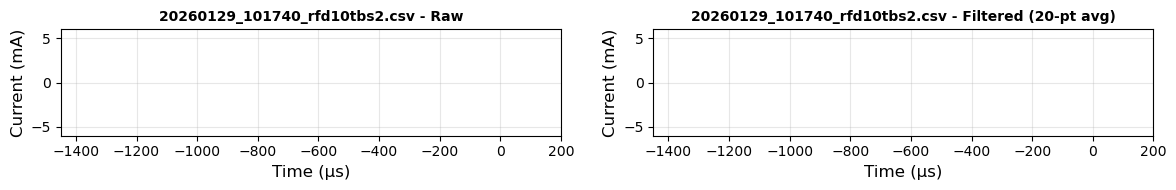


Plotting: 20260129 101851 (1 files)


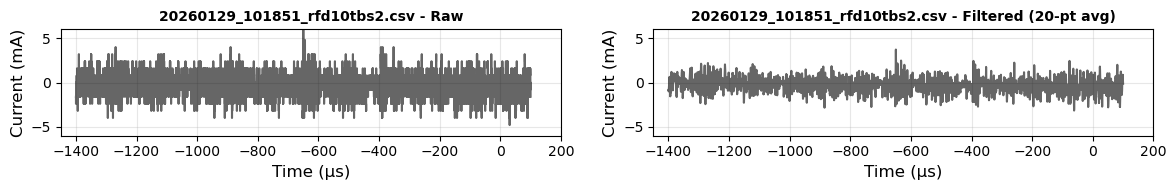


Plotting: 20260129 101918 (8 files)


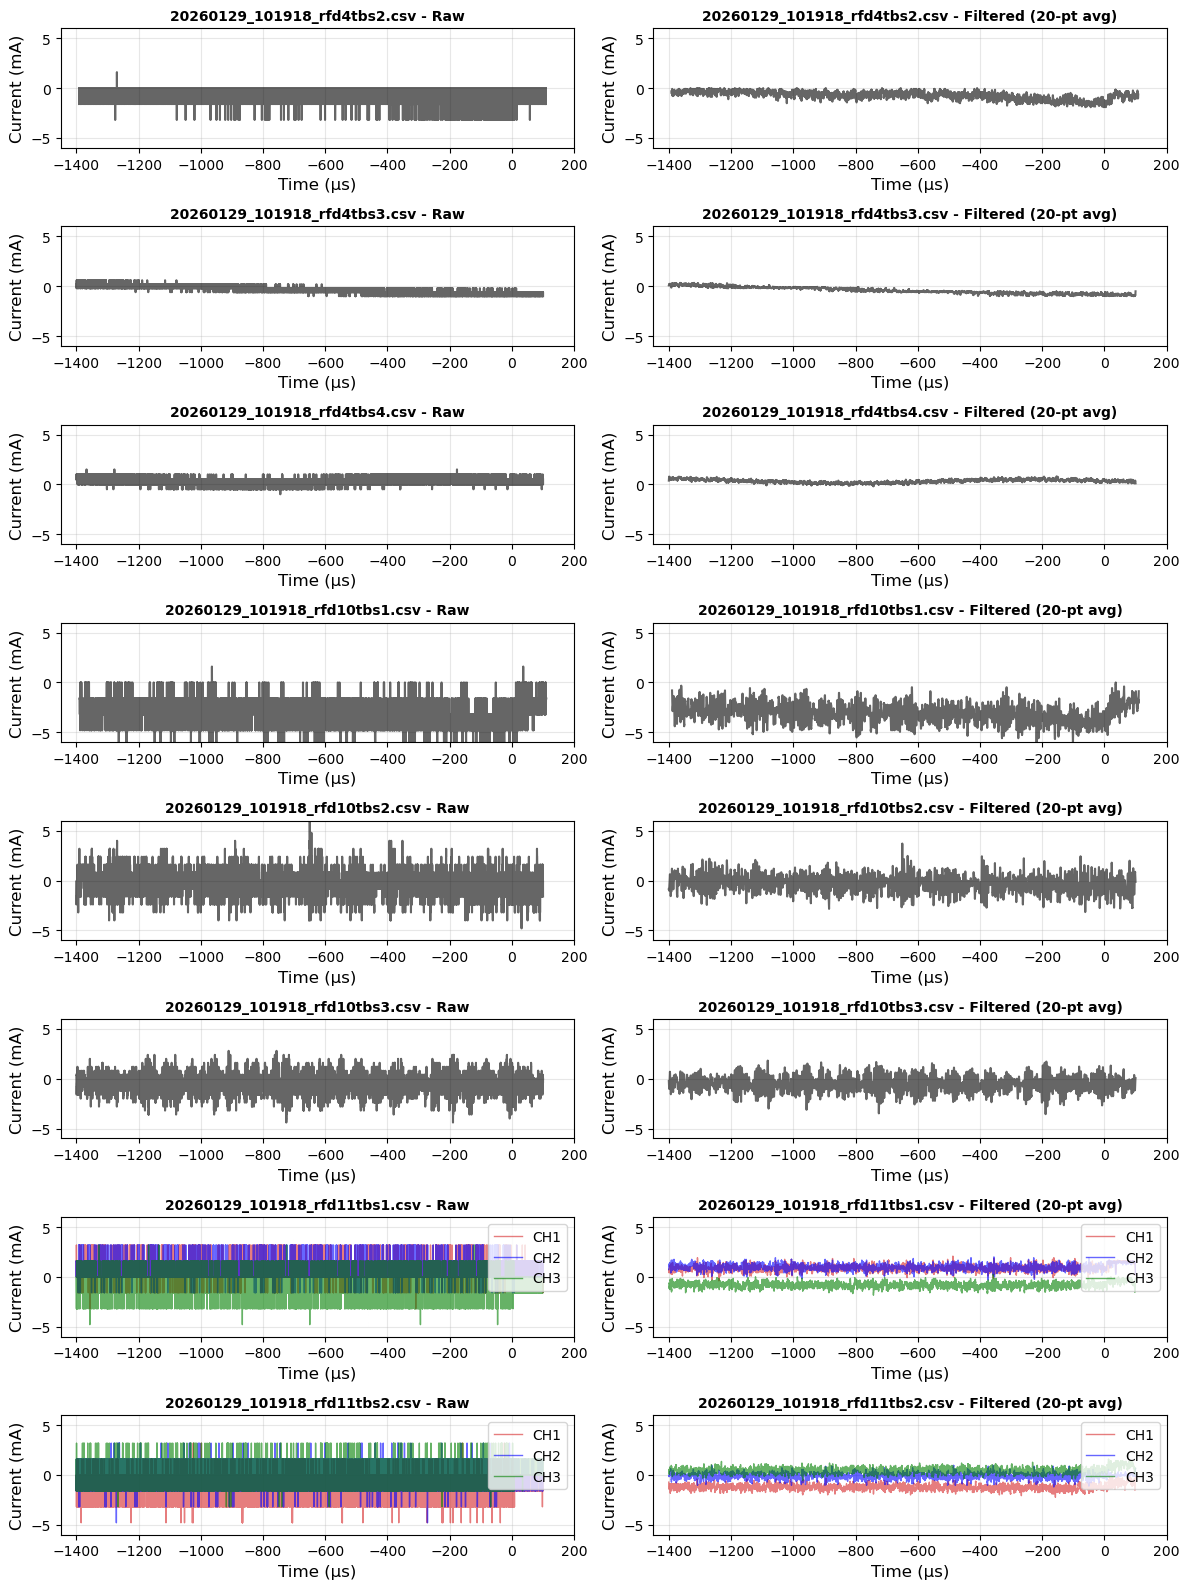


Plotting: 20260129 102034 (2 files)


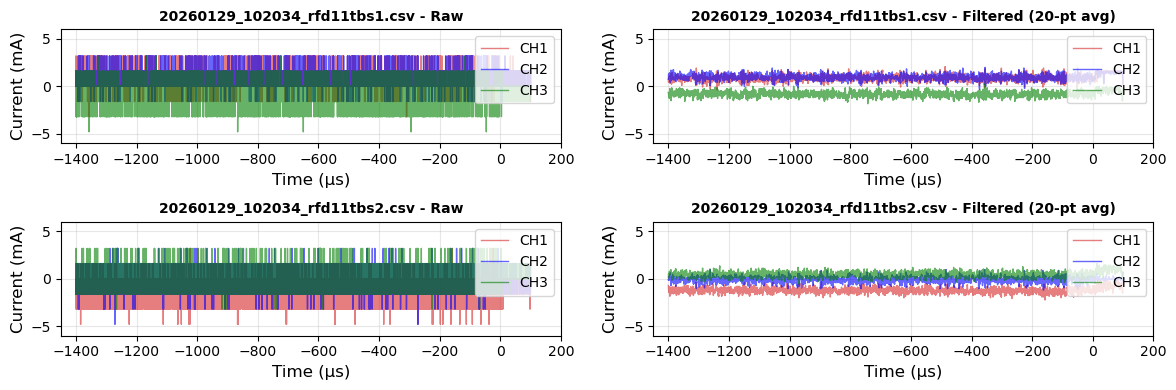


PLOTTING PROBLEMATIC FILES (peak > 5 mA)


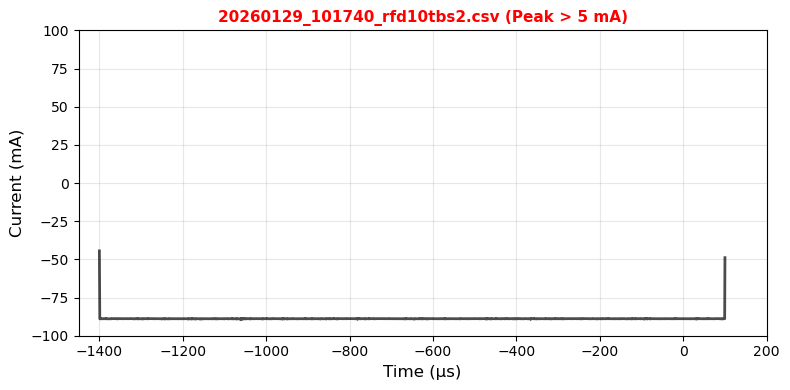

Plotted: 20260129_101740_rfd10tbs2.csv


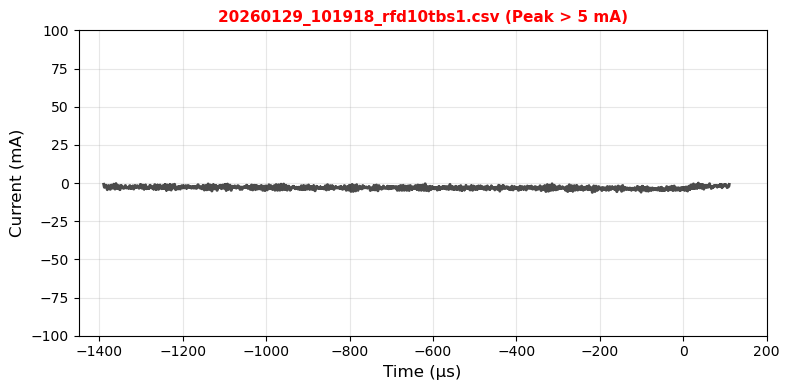

Plotted: 20260129_101918_rfd10tbs1.csv


In [8]:
# ===== DISCOVER AND OPTIONAL PLOT BY DATE/TIME =====
# Find all unique date/time combinations and plot them chronologically (if enabled)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt
from pathlib import Path

data_folder = Path("/Users/xylu/Desktop/Data/electrode_local")
all_files = sorted(data_folder.glob("*.csv"))

print(f"Total files found: {len(all_files)}")

# Extract unique (date, time) pairs
date_time_pairs = set()
for file in all_files:
    stem = file.stem
    parts = stem.split('_')
    if len(parts) >= 2:
        date_str = parts[0]
        time_str = parts[1]
        date_time_pairs.add((date_str, time_str))

# Sort chronologically
sorted_date_times = sorted(date_time_pairs, key=lambda x: (x[0], x[1]))

# Filter by selected dates if specified
if selected_dates:
    # Convert selected_dates to strings for comparison
    selected_dates_str = [str(d) for d in selected_dates]
    sorted_date_times = [dt for dt in sorted_date_times if dt[0] in selected_dates_str]
    print(f"Filtering to {len(sorted_date_times)} date/time combination(s) matching selected dates: {selected_dates}\n")
else:
    print(f"Found {len(sorted_date_times)} unique date/time combinations:\n")

# for date_str, time_str in sorted_date_times:
#     print(f"  {date_str} {time_str}")

# Pre-calculated time shifts for each file type (in µs). These shifts align the rising edge to the target times
time_shifts = {
    'rfd4tbs2': 8.707,     # edge -3.050 -> target 5.657
    'rfd10tbs1': 10.320,   # edge -4.625 -> target 5.695
    'rfd11tbs1': -0.205,   # edge 6.400 -> target 6.195
    'rfd11tbs2': -0.205    # edge 6.400 -> target 6.195
}

# Channel colors
color_map = {'CH1': '#d62728', 'CH2': 'blue', 'CH3': 'green'}

# ===== HELPER FUNCTIONS =====

def group_files_by_rfd(matching_files):
    """Group and sort files by RFD type and TBS value."""
    rfd4_files = sorted([f for f in matching_files if 'rfd4' in f.name])
    rfd10_files = sorted([f for f in matching_files if 'rfd10' in f.name])
    rfd11_files = sorted([f for f in matching_files if 'rfd11' in f.name])
    
    # Sort within each RFD by TBS value
    rfd4_files = sorted(rfd4_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    rfd10_files = sorted(rfd10_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    rfd11_files = sorted(rfd11_files, key=lambda f: int(f.stem.split('tbs')[1]) if 'tbs' in f.stem else 0)
    
    # Combine in order: rfd4, rfd10, rfd11
    return rfd4_files + rfd10_files + rfd11_files


def read_and_process_file(file_path):
    """Read file, apply filter, and convert to current in mA.
    
    Returns:
        dict: Contains 'df', 'channels', 'raw_current_data', 'current_data', 'time_us', 'is_rfd11', 'peak_currents'
    """
    title_name = file_path.name
    is_rfd11 = 'rfd11' in title_name
    
    # Read appropriate channels
    if is_rfd11:
        df = pd.read_csv(file_path, skiprows=4, usecols=['CH1', 'CH2', 'CH3'])
        channels = ['CH1', 'CH2', 'CH3']
    else:
        df = pd.read_csv(file_path, skiprows=4, usecols=['CH1'])
        channels = ['CH1']
    
    # Calculate time in microseconds
    ### Physics Line ###
    time_us = np.arange(len(df)) * 75e-9 * 1e6 - 1400
    
    # Extract file identifier and apply time shift
    file_id = file_path.stem.split('_')[-1]  # e.g., 'rfd4tbs2'
    if file_id in time_shifts:
        time_us = time_us + time_shifts[file_id]
    
    # Process each channel
    raw_current_data = {}
    current_data = {}
    peak_currents = {}
    
    for ch_name in channels:
        ch_data = df[ch_name].values.copy()
        
        # Convert raw data to current in mA first
        ### Physics Line ###
        raw_current_mA = ch_data / 10/50 * 1000  # Note:10 times voltage probe, 50 ohm resistor, convert to mA
        raw_current_data[ch_name] = raw_current_mA
        
        # Apply 20-point moving average filter to raw current
        ### Physics Line ###
        window_size = 20
        filtered_current_mA = np.convolve(raw_current_mA, np.ones(window_size)/window_size, mode='same')
        current_data[ch_name] = filtered_current_mA
        
        # Calculate peak from filtered data
        peak_currents[ch_name] = np.max(np.abs(filtered_current_mA))
    
    return {
        'df': df,
        'channels': channels,
        'raw_current_data': raw_current_data,
        'current_data': current_data,
        'time_us': time_us,
        'is_rfd11': is_rfd11,
        'peak_currents': peak_currents,
        'filename': title_name
    }


# ===== PROCESS ALL FILES ONCE AND STORE RESULTS =====
print("\n" + "="*60)
print("PROCESSING ALL FILES")
print("="*60)

all_file_data = []  # Store all processed file data

for date_str, time_str in sorted_date_times:
    search_pattern = f"{date_str}_{time_str}_*.csv"
    matching_files = sorted(data_folder.glob(search_pattern))
    
    if not matching_files:
        continue
    
    # Group by RFD type and TBS value
    file_paths = group_files_by_rfd(matching_files)
    
    if not file_paths:
        continue
    
    print(f"\n{date_str} {time_str}: Processing {len(file_paths)} files...")
    
    # Process each file once
    for file_path in file_paths:
        try:
            file_data = read_and_process_file(file_path)
            file_data['date'] = date_str
            file_data['time'] = time_str
            all_file_data.append(file_data)
            print(f"  ✓ {file_data['filename']}")
        except Exception as e:
            print(f"  ✗ Error processing {file_path.name}: {e}")

print(f"\nSuccessfully processed {len(all_file_data)} files.")

# ===== PEAK CURRENT ANALYSIS =====
# Check which files have peak currents exceeding 5 mA on any channel
print("\n" + "="*60)
print("PEAK CURRENT ANALYSIS (>5 mA threshold)")
print("="*60)

peak_results = []

for file_data in all_file_data:
    has_peak_over_5 = any(peak > 5 for peak in file_data['peak_currents'].values())
    
    if has_peak_over_5:
        peak_results.append({
            'date': file_data['date'],
            'time': file_data['time'],
            'filename': file_data['filename'],
            'peaks': file_data['peak_currents']
        })

# Print summary
if peak_results:
    print(f"\nFound {len(peak_results)} file(s) with peak current > 5 mA:\n")
    for result in peak_results:
        print(f"  {result['date']} {result['time']} - {result['filename']}")
        for ch, peak in result['peaks'].items():
            if peak > 5:
                print(f"    {ch}: {peak:.2f} mA ⚠️")
            else:
                print(f"    {ch}: {peak:.2f} mA")
else:
    print("\nNo files found with peak current > 5 mA on any channel.")

# ===== OPTIONAL PLOTTING OF ALL TRACES =====
if plot_all_traces.upper() == "Y":
    print("\n" + "="*60)
    print("PLOTTING ALL TRACES")
    print("="*60)
    
    # Group files by date/time for plotting
    from collections import defaultdict
    date_time_groups = defaultdict(list)
    for file_data in all_file_data:
        key = (file_data['date'], file_data['time'])
        date_time_groups[key].append(file_data)
    
    for (date_str, time_str), file_data_list in sorted(date_time_groups.items()):
        print(f"\nPlotting: {date_str} {time_str} ({len(file_data_list)} files)")
        
        # Create subplots - 2 columns (raw on left, filtered on right)
        n_plots = len(file_data_list)
        fig, axes = plt.subplots(n_plots, 2, figsize=(12, 2 * n_plots))
        if n_plots == 1:
            axes = axes.reshape(1, -1)  # Make it 2D array for single row
        
        # Plot each file
        for idx, file_data in enumerate(file_data_list):
            # Left plot: Raw current
            for ch_name in file_data['channels']:
                raw_current_mA = file_data['raw_current_data'][ch_name]
                
                if file_data['is_rfd11']:
                    axes[idx, 0].plot(file_data['time_us'], raw_current_mA, color=color_map[ch_name], 
                              linewidth=1, marker=None, markersize=1, alpha=0.6, label=ch_name)
                else:
                    axes[idx, 0].plot(file_data['time_us'], raw_current_mA, color='black', 
                              linewidth=1.5, marker=None, markersize=1, alpha=0.6)
            
            axes[idx, 0].set_xlabel('Time (µs)', fontsize=12)
            axes[idx, 0].set_ylabel('Current (mA)', fontsize=12)
            axes[idx, 0].set_title(f'{file_data["filename"]} - Raw', fontsize=10, fontweight='bold')
            axes[idx, 0].grid(True, alpha=0.3)
            axes[idx, 0].tick_params(labelsize=10)
            axes[idx, 0].set_ylim(-6, 6)
            axes[idx, 0].set_xlim(-1450, 200)
            
            if file_data['is_rfd11']:
                axes[idx, 0].legend(fontsize=10, loc='upper right')
            
            # Right plot: Filtered current
            for ch_name in file_data['channels']:
                filtered_current_mA = file_data['current_data'][ch_name]
                
                if file_data['is_rfd11']:
                    axes[idx, 1].plot(file_data['time_us'], filtered_current_mA, color=color_map[ch_name], 
                              linewidth=1, marker=None, markersize=1, alpha=0.6, label=ch_name)
                else:
                    axes[idx, 1].plot(file_data['time_us'], filtered_current_mA, color='black', 
                              linewidth=1.5, marker=None, markersize=1, alpha=0.6)
            
            axes[idx, 1].set_xlabel('Time (µs)', fontsize=12)
            axes[idx, 1].set_ylabel('Current (mA)', fontsize=12)
            axes[idx, 1].set_title(f'{file_data["filename"]} - Filtered (20-pt avg)', fontsize=10, fontweight='bold')
            axes[idx, 1].grid(True, alpha=0.3)
            axes[idx, 1].tick_params(labelsize=10)
            axes[idx, 1].set_ylim(-6, 6)
            axes[idx, 1].set_xlim(-1450, 200)
            
            if file_data['is_rfd11']:
                axes[idx, 1].legend(fontsize=10, loc='upper right')
        
        plt.tight_layout()
        plt.show()

# ===== PLOT ONLY PROBLEMATIC FILES =====
if peak_results:
    print("\n" + "="*60)
    print("PLOTTING PROBLEMATIC FILES (peak > 5 mA)")
    print("="*60)

    # Create a lookup dict for quick access
    problematic_filenames = {result['filename'] for result in peak_results}
    
    for file_data in all_file_data:
        if file_data['filename'] not in problematic_filenames:
            continue

        # Create single subplot for this problematic file
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))

        # Plot each channel
        for ch_name in file_data['channels']:
            current_mA = file_data['current_data'][ch_name]
            
            if file_data['is_rfd11']:
                ax.plot(file_data['time_us'], current_mA, color=color_map[ch_name], linewidth=1.5,
                        marker=None, markersize=1, alpha=0.7, label=ch_name)
            else:
                ax.plot(file_data['time_us'], current_mA, color='black', linewidth=2,
                        marker=None, markersize=1, alpha=0.7)

        ax.set_xlabel('Time (µs)', fontsize=12)
        ax.set_ylabel('Current (mA)', fontsize=12)
        ax.set_title(f'{file_data["filename"]} (Peak > 5 mA)', fontsize=11, fontweight='bold', color='red')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=10)
        ax.set_ylim(-100, 100)
        ax.set_xlim(-1450, 200)

        if file_data['is_rfd11']:
            ax.legend(fontsize=10, loc='upper right')

        plt.tight_layout()
        plt.show()

        print(f"Plotted: {file_data['filename']}")
else:
    print("\nNo files found with peak current > 5 mA on any channel.")
